In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Load the data
df = pd.read_csv('UNSW_NB15_training-set.csv')

# 2. Basic Cleaning: Drop columns that aren't useful for patterns
# We drop 'id' and 'attack_cat' because we want the AI to find the attack itself
df_clean = df.drop(['id', 'attack_cat', 'label'], axis=1)

# 3. Encoding: Turn text (TCP, UDP, http) into numbers for the AI
le = LabelEncoder()
for col in ['proto', 'service', 'state']:
    df_clean[col] = le.fit_transform(df_clean[col])

print("Data is ready for AI processing!")

Data is ready for AI processing!


In [2]:
from sklearn.ensemble import IsolationForest

# Define the model
# contamination=0.1 means we expect roughly 10% of the logs might be 'anomalies'
model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)

# Train the model (This is the "Learning" phase)
model.fit(df_clean)

# Predict anomalies: 1 = Normal, -1 = Anomaly (Potential Threat)
df['is_anomaly'] = model.predict(df_clean)

# Calculate anomaly score (Closer to -1 means higher threat)
df['threat_score'] = model.decision_function(df_clean)

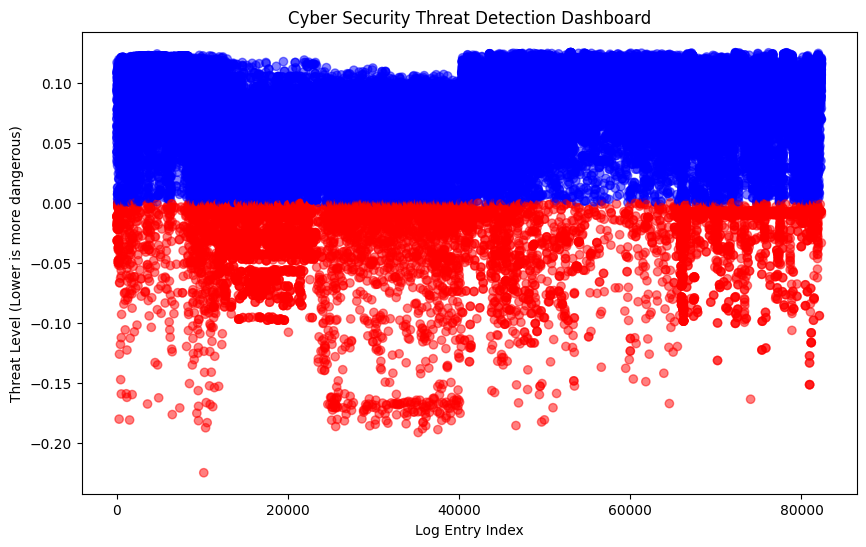

In [3]:
import matplotlib.pyplot as plt

# Plotting normal vs anomalies
plt.figure(figsize=(10,6))
colors = {1: 'blue', -1: 'red'}
plt.scatter(df.index, df['threat_score'], c=df['is_anomaly'].map(colors), alpha=0.5)
plt.title("Cyber Security Threat Detection Dashboard")
plt.xlabel("Log Entry Index")
plt.ylabel("Threat Level (Lower is more dangerous)")
plt.show()